In [1]:
from tools.SCST import SCST

In [2]:
class Args:
    track_thresh = 0.5
    match_thresh = 0.5
    track_buffer = 60
    mot20 = False
    cpu_workers = 10   # 듀얼 CPU 적극 활용
    chunk_sec   = 10.0 # 15~30초 권장
args = Args()

In [3]:
plan_pts  = [
            (3588, 412),    #point1
            (3588, 1036),   #point2
            (3588, 1657),   #point3
            (2225, 412),    #point4
            (2225, 1036),   #point5
            (2225, 1657),   #point6
            (861, 412),     #point7
            (861, 1036),    #point8
            (861, 1657),    #point9
             ]


In [13]:
cam_pts = [
            (1390, 521),  #point1
            (1618, 552),  #point2
            (1784, 578),  #point3
            (1112, 564),  #point4
            (1434,620),   #point5
            (1709,668),   #point6
            (481,651),    #point7
            (852,809),    #point8
            (1393,1007)   #point9
            ]


test = SCST(
    cctv_url="rtsp://210.99.70.120:1935/live/cctv001.stream",
    cctv_benchmark= cam_pts,
    plan_path="/workspace/assets/25082_homograph_coordinate-plane.jpg",
    plan_benchmark= plan_pts,
    tracker_args= args
)


Loads checkpoint by local backend from path: /workspace/PretrainedModel_by_JeonYT/vehicle/epoch_54.pth
[DEBUG] VehicleDetector loaded on device=cuda:0
Parameter device: cuda:0
Loads checkpoint by local backend from path: /workspace/PretrainedModel_by_JeonYT/worker/epoch_100.pth
[DEBUG] WorkerDetector loaded on device=cuda:1
Parameter device: cuda:1


In [14]:
while True:
    cam = test._videoCapture()
    cordinate, result = test.run()
    print(cordinate)

[{'id': 22, 'bbox': array([526.41174 ,  22.377365, 111.264946, 434.17914 ], dtype=float32), 'score': 0.6861242651939392, 'pt': (2408.80859375, -1290.158447265625)}]
[{'id': 22, 'bbox': array([526.5654  ,  30.923368, 110.767944, 432.16382 ], dtype=float32), 'score': 1.1861028671264648, 'pt': (2325.5791015625, -1174.0020751953125)}]
[{'id': 22, 'bbox': array([526.333   ,  26.667213, 111.35745 , 434.4725  ], dtype=float32), 'score': 0.961134672164917, 'pt': (2349.854736328125, -1207.76953125)}]
[{'id': 22, 'bbox': array([526.4953  ,  26.43981 , 110.930016, 432.6986  ], dtype=float32), 'score': 1.3141146898269653, 'pt': (2375.08984375, -1243.25439453125)}]
[{'id': 22, 'bbox': array([527.97253 ,  33.216682, 107.70189 , 419.09302 ], dtype=float32), 'score': 2.606564521789551, 'pt': (2465.59521484375, -1370.3863525390625)}, {'id': 23, 'bbox': array([488.12875  ,  64.830734 ,   7.5165467,  21.355158 ], dtype=float32), 'score': 0.9306442737579346, 'pt': (-2289.559814453125, 5590.75244140625)}]


KeyboardInterrupt: 

[]


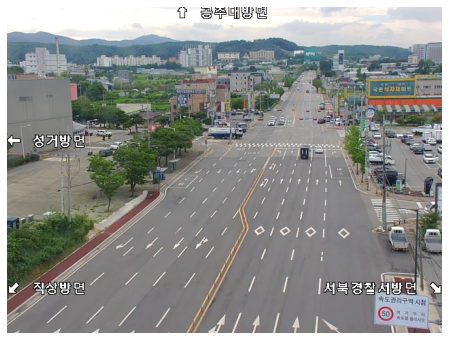

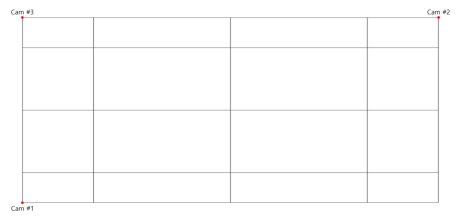

In [ ]:
import cv2
import matplotlib.pyplot as plt


print(cordinate)
img_rgb = cv2.cvtColor(cam, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

img_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()